In [1]:
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
image_path = "/content/drive/MyDrive/AI and ML/image.avif"
img = Image.open

Exercise - 1:

In [7]:
img = Image.open(image_path)
img.show()

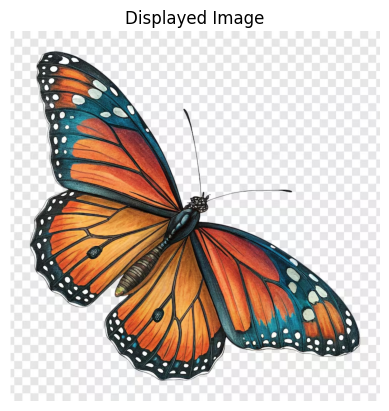

In [8]:
plt.imshow(img)
plt.axis('off')  # Hide axis numbers
plt.title("Displayed Image")
plt.show()

In [9]:
import numpy as np

In [10]:
img_array = np.array(img)

In [11]:
top_left = img_array[0:100, 0:100]  # Rows 0-99, Columns 0-99

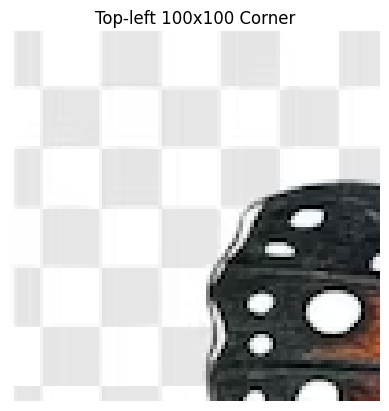

In [12]:
plt.imshow(top_left)
plt.axis('off')
plt.title("Top-left 100x100 Corner")
plt.show()

In [13]:
import matplotlib.pyplot as plt

# Convert the image to a NumPy array
img_array = np.array(img)

In [14]:
# Extract Red, Green, and Blue channels
R = img_array[:, :, 0]  # All rows, all columns, channel 0
G = img_array[:, :, 1]  # All rows, all columns, channel 1
B = img_array[:, :, 2]  # All rows, all columns, channel 2

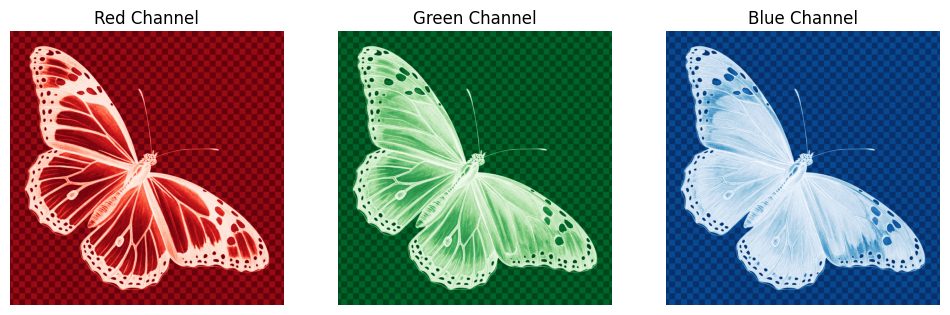

In [15]:
plt.figure(figsize=(12, 4))

# Red channel
plt.subplot(1, 3, 1)
plt.imshow(R, cmap='Reds')  # Use Reds colormap
plt.title("Red Channel")
plt.axis('off')

# Green channel
plt.subplot(1, 3, 2)
plt.imshow(G, cmap='Greens')  # Use Greens colormap
plt.title("Green Channel")
plt.axis('off')

# Blue channel
plt.subplot(1, 3, 3)
plt.imshow(B, cmap='Blues')  # Use Blues colormap
plt.title("Blue Channel")
plt.axis('off')

plt.show()

In [16]:
# Set top-left 100x100 pixels to 210 (light gray)
img_array[0:100, 0:100, :] = 210

In [17]:
# Set top-left 100x100 pixels to 210 (light gray)
img_array[0:100, 0:100, :] = 210

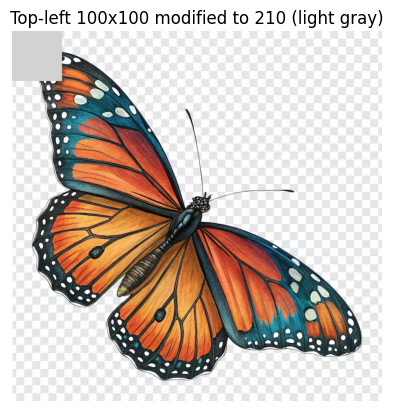

In [18]:
# Convert NumPy array back to PIL Image
modified_img = Image.fromarray(img_array)

# Display using Pillow
modified_img.show()

# Display using matplotlib
plt.imshow(modified_img)
plt.axis('off')
plt.title("Top-left 100x100 modified to 210 (light gray)")
plt.show()

Exercise - 2:

In [19]:
image_path = "/content/drive/MyDrive/AI and ML/image.avif"
gray_img = Image.open(image_path).convert('L')  # 'L' converts to grayscale

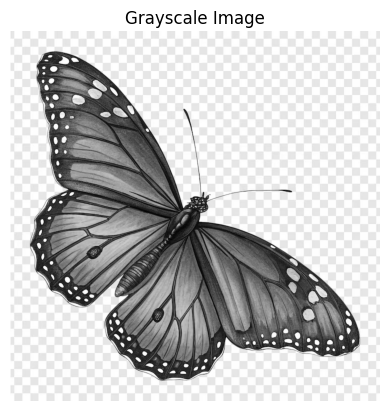

In [20]:
plt.imshow(gray_img, cmap='gray')  # Use grayscale colormap
plt.axis('off')  # Hide axes
plt.title("Grayscale Image")
plt.show()

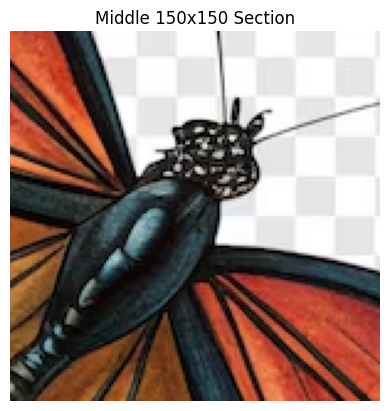

In [23]:
# Image dimensions
height, width = img_array.shape[:2]

# Center coordinates
center_y = height // 2
center_x = width // 2

# Half size for 150x150 section
half_size = 150 // 2

# Extract middle section
middle_section = img_array[
    center_y - half_size : center_y + half_size,
    center_x - half_size : center_x + half_size
]

# Display the cropped middle section
plt.imshow(middle_section, cmap='gray')
plt.axis('off')
plt.title("Middle 150x150 Section")
plt.show()

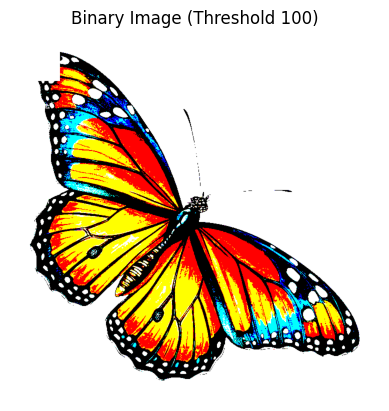

In [24]:
# Apply threshold
threshold_value = 100
binary_img = np.where(img_array < threshold_value, 0, 255).astype(np.uint8)

# Display binary image
plt.imshow(binary_img, cmap='gray')
plt.axis('off')
plt.title("Binary Image (Threshold 100)")
plt.show()

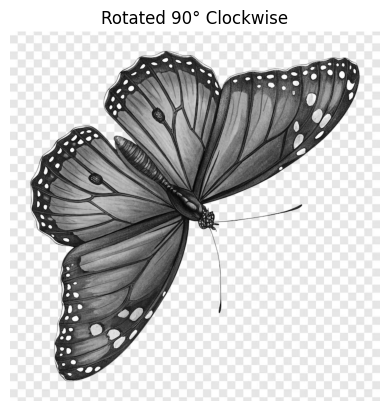

In [25]:
# Rotate 90 degrees clockwise using Pillow
rotated_img = gray_img.rotate(-90, expand=True)  # -90 for clockwise

# Display rotated image
plt.imshow(rotated_img, cmap='gray')
plt.axis('off')
plt.title("Rotated 90° Clockwise")
plt.show()

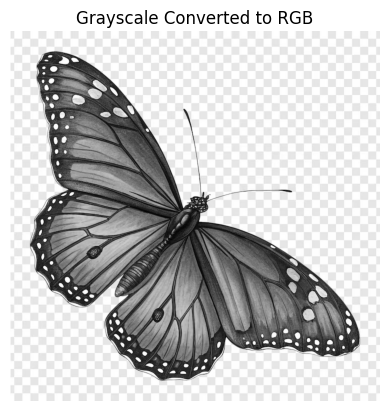

In [26]:
# Convert grayscale to RGB
rgb_img = gray_img.convert('RGB')

# Display RGB image
plt.imshow(rgb_img)
plt.axis('off')
plt.title("Grayscale Converted to RGB")
plt.show()

3 Image Compression and Decompression using PCA.

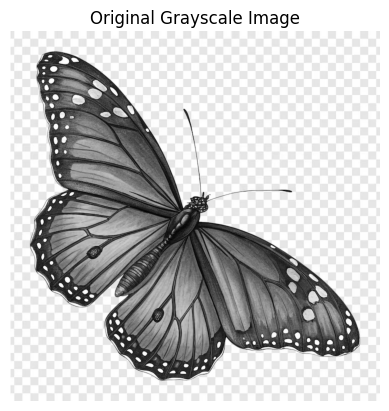

In [28]:
# Load the image (replace with your image path)
image_path = "/content/drive/MyDrive/AI and ML/image.avif"
img = Image.open(image_path).convert('L')  # Convert to grayscale

# Convert to NumPy array
img_array = np.array(img, dtype=float)  # Float for PCA

# Display original image
plt.imshow(img_array, cmap='gray')
plt.axis('off')
plt.title("Original Grayscale Image")
plt.show()

In [29]:
# Flatten the image to 2D if needed (height x width)
height, width = img_array.shape

# Standardize (center the data)
mean_vector = np.mean(img_array, axis=0)  # Mean of each column
centered_data = img_array - mean_vector

# Verify mean ~ 0
print("Mean of centered data (should be close to 0):", np.mean(centered_data))

Mean of centered data (should be close to 0): 6.377756856844493e-16


In [30]:
# Compute covariance matrix
cov_matrix = np.cov(centered_data.T)  # Transpose so features are columns
print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (740, 740)


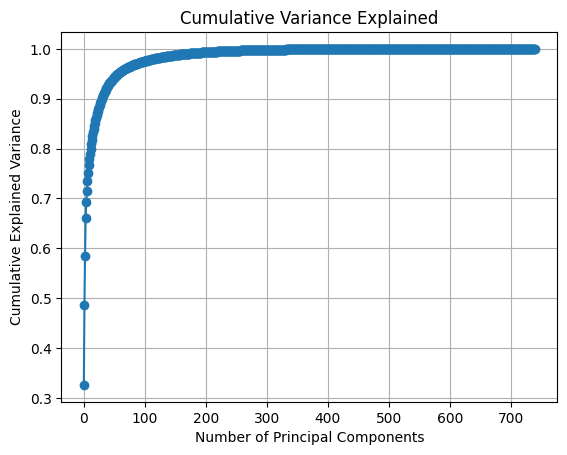

In [31]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # For symmetric matrices

# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Explained variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative variance
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained")
plt.grid()
plt.show()

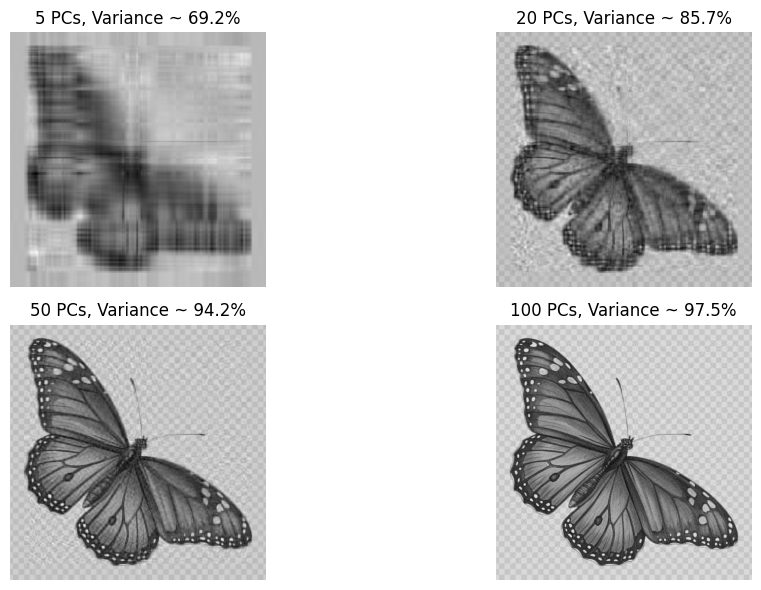

In [32]:
# Function to reconstruct image with top k PCs
def reconstruct_image(centered_data, eigenvectors, k, mean_vector):
    top_eigenvectors = eigenvectors[:, :k]        # Select top k eigenvectors
    lower_dim = centered_data @ top_eigenvectors  # Project to lower dimension
    reconstructed = lower_dim @ top_eigenvectors.T + mean_vector  # Back to original
    return reconstructed

# Experiment with 4 different numbers of PCs
pcs_list = [5, 20, 50, 100]  # Example number of PCs

plt.figure(figsize=(12, 6))
for i, k in enumerate(pcs_list, 1):
    reconstructed = reconstruct_image(centered_data, eigenvectors, k, mean_vector)

    plt.subplot(2, 2, i)
    plt.imshow(reconstructed, cmap='gray')
    plt.axis('off')
    plt.title(f"{k} PCs, Variance ~ {cumulative_variance[k-1]*100:.1f}%")

plt.tight_layout()
plt.show()